# Charge Gate Ramsey Analysis
Load a pre-parsed `xarray.Dataset` from an `.h5` file and run `ChargeGateRamseyAnalyzer`.

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from scqat.protocols.charge_gate_ramsey import ChargeGateRamseyAnalyzer
from scqat.parsers.xarray_h5_parser import load_xarray_h5
from scqat.parsers.qualibrate_parser import repetition_data

## 1. Configuration

In [2]:
# Path to the pre-parsed xarray Dataset stored as NetCDF4/HDF5
H5_PATH = r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q2\ng01_ref0165_test04\ng_ramsey_statistic\#2824_LCH_charge_gate_ramsey_10_022801\ds_raw.h5"

# Optional: directory for saving outputs (set to None to skip saving)
OUTPUT_DIR = None

# Name of the variable in the dataset to use as the signal
# Common choices: "state", "I"
SIGNAL_VAR = "I"

# Optional analysis kwargs
ANALYSIS_KWARGS = {
    # "force_model": "beat",       # force damped beat for every charge-gate slice
    "f_c_fixed": 0.2e-3 *1000,        # user-supplied centre frequency (skip auto-calc)
    # "abscos_frequency_hint": 0.6,  # seed for |cos| fit frequency (V⁻¹)
    "abscos_phase_bounds": (-0.5, 0.5),  # (min, max) bounds for |cos| phase parameter
}

## 2. Load Dataset

In [ ]:
dataset = load_xarray_h5(H5_PATH)

voltage_to_charge_factor = 0.5376 #Q1
voltage_to_charge_factor = 0.59 #Q2
dataset = dataset.assign_coords(
    # charge_gate=dataset.charge_gate * voltage_to_charge_factor,
    idle_time=dataset.idle_time / 1000,
)
dataset

<xarray.Dataset> Size: 37kB
Dimensions:      (charge_gate: 25, qubit: 1, idle_time: 60)
Coordinates:
  * charge_gate  (charge_gate) float64 200B -0.48 -0.44 -0.4 ... 0.4 0.44 0.48
  * qubit        (qubit) object 8B 'q1'
  * idle_time    (idle_time) float64 480B 0.016 1.032 2.048 ... 57.96 58.98 60.0
Data variables:
    I1           (qubit, charge_gate, idle_time) int32 6kB 0 0 0 0 0 ... 0 0 0 0
    Q1           (qubit, charge_gate, idle_time) int32 6kB 0 0 0 0 0 ... 0 0 0 0
    I            (qubit, charge_gate, idle_time) float64 12kB -0.0002455 ... ...
    Q            (qubit, charge_gate, idle_time) float64 12kB -0.00248 ... -0...

In [9]:
# Split by qubit and pick the first one
sq_data = repetition_data(dataset)[0]

# Rename the chosen variable to 'signal' so the analyzer can find it
if SIGNAL_VAR != 'signal' and SIGNAL_VAR in sq_data:
    sq_data = sq_data.rename({SIGNAL_VAR: 'signal'})

sq_data

<xarray.Dataset> Size: 37kB
Dimensions:      (charge_gate: 25, idle_time: 60)
Coordinates:
  * charge_gate  (charge_gate) float64 200B -0.48 -0.44 -0.4 ... 0.4 0.44 0.48
    qubit        <U2 8B 'q1'
  * idle_time    (idle_time) float64 480B 0.016 1.032 2.048 ... 57.96 58.98 60.0
Data variables:
    I1           (charge_gate, idle_time) int32 6kB 0 0 0 0 0 0 ... 0 0 0 0 0 0
    Q1           (charge_gate, idle_time) int32 6kB 0 0 0 0 0 0 ... 0 0 0 0 0 0
    signal       (charge_gate, idle_time) float64 12kB -0.0002455 ... 0.0002793
    Q            (charge_gate, idle_time) float64 12kB -0.00248 ... -0.001628

## 3. Run Analysis

In [10]:
analyzer = ChargeGateRamseyAnalyzer()
results, figs = analyzer.analyze(
    sq_data,
    output_dir=OUTPUT_DIR,
    **ANALYSIS_KWARGS,
)

## 4. Display Figures

--- raw_colormap ---


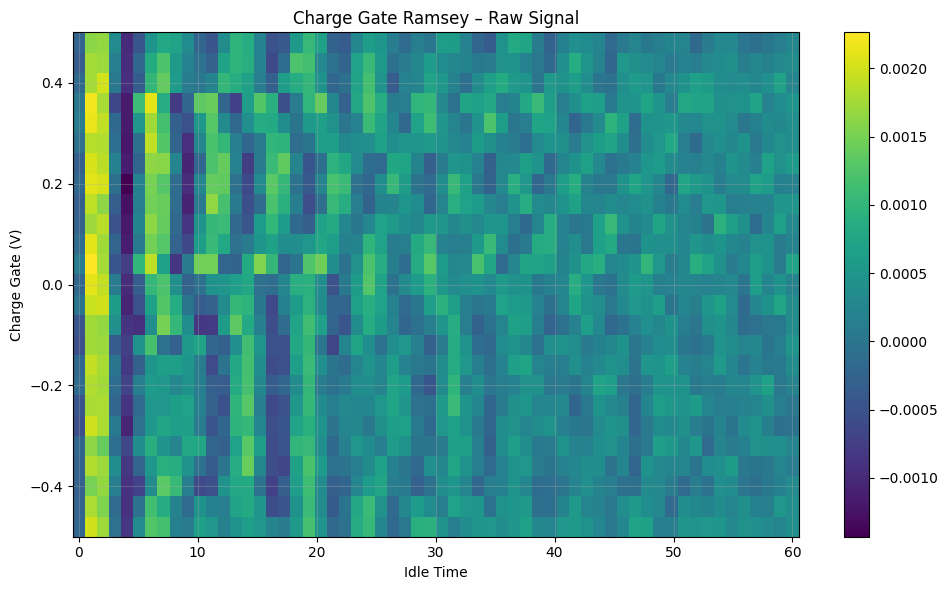

--- fft_spectrum ---


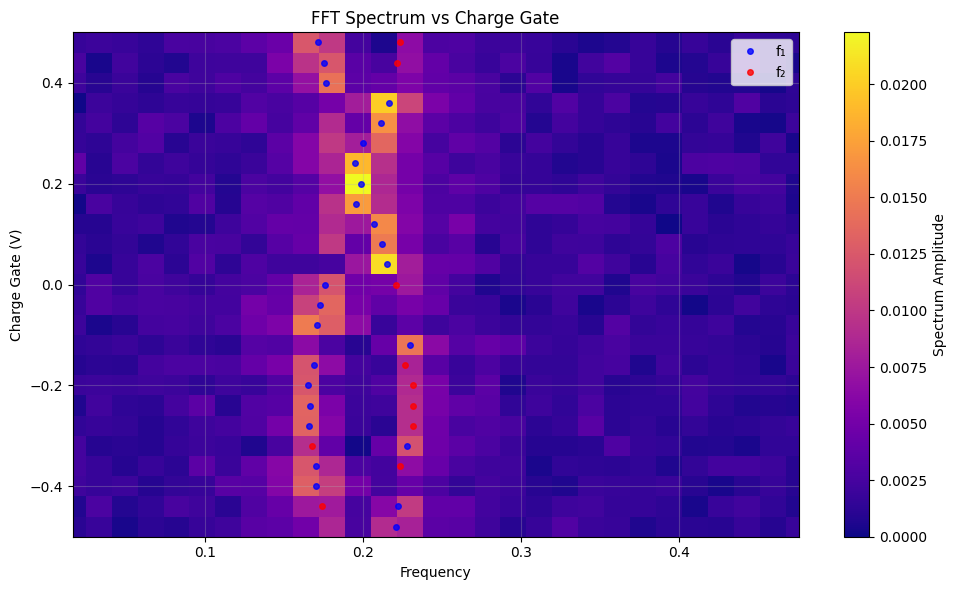

--- fft_spectrum_with_fit ---


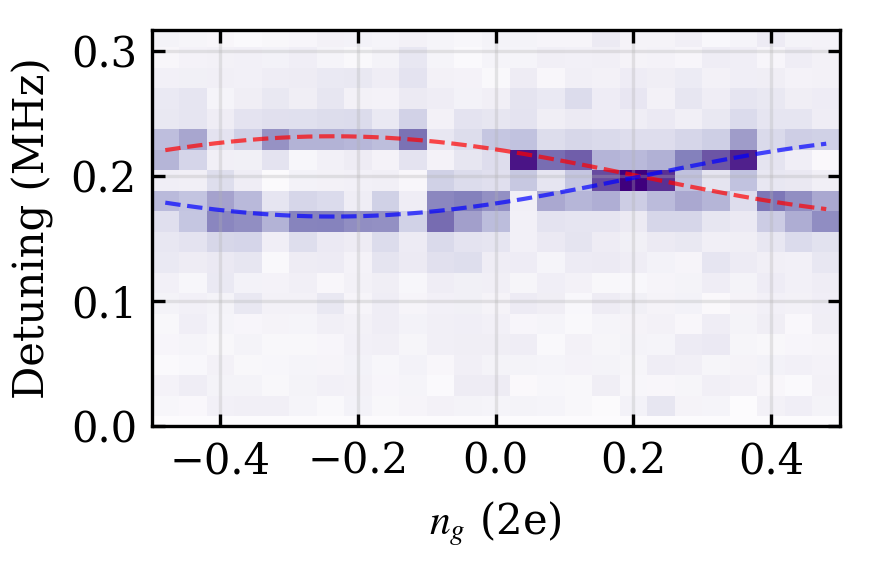

--- freq_vs_charge_gate ---


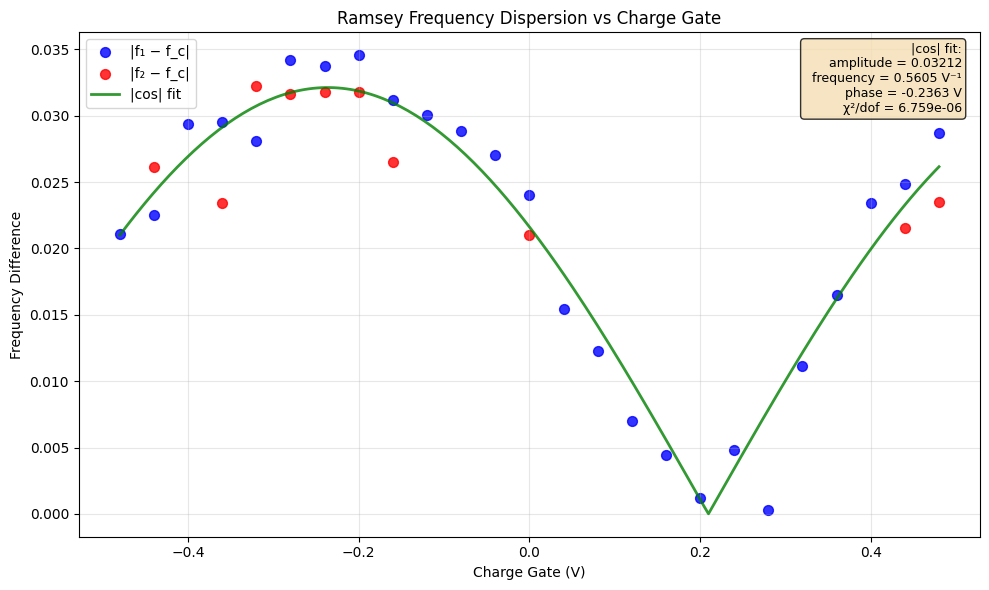

In [11]:
for name, fig in figs.items():
    print(f"--- {name} ---")
    display(fig)
    plt.close(fig)

## 5. Inspect Results

In [12]:
import numpy as np

print(f"Centre frequency f_c = {results['f_c']:.6g}")
print()

# Per charge-gate summary
for i, cg in enumerate(results['charge_gates']):
    mt = results['model_types'][i]
    f1 = results['f_1'][i]
    f2 = results['f_2'][i]
    line = f"  charge_gate={cg:.4f}  model={mt or 'FAILED':>6s}  f_1={f1:.6g}"
    if not np.isnan(f2):
        line += f"  f_2={f2:.6g}"
    print(line)

# |cos| fit summary
print()
abscos = results.get('abscos_params')
if abscos and abscos.get('success'):
    print("|cos| fit results:")
    print(f"  amplitude = {abscos['amplitude']:.6g}")
    print(f"  frequency = {abscos['frequency']:.6g} V⁻¹")
    print(f"  phase     = {abscos['phase']:.6g} V")
    print(f"  χ²/dof    = {abscos['redchi']:.6g}")
else:
    print("|cos| fit did not converge or insufficient data.")

Centre frequency f_c = 0.2

  charge_gate=-0.4800  model=single  f_1=0.221056
  charge_gate=-0.4400  model=  beat  f_1=0.222531  f_2=0.173871
  charge_gate=-0.4000  model=single  f_1=0.170629
  charge_gate=-0.3600  model=  beat  f_1=0.170464  f_2=0.22345
  charge_gate=-0.3200  model=  beat  f_1=0.228116  f_2=0.167757
  charge_gate=-0.2800  model=  beat  f_1=0.165781  f_2=0.231665
  charge_gate=-0.2400  model=  beat  f_1=0.166228  f_2=0.231783
  charge_gate=-0.2000  model=  beat  f_1=0.165447  f_2=0.23177
  charge_gate=-0.1600  model=  beat  f_1=0.168797  f_2=0.226524
  charge_gate=-0.1200  model=single  f_1=0.230078
  charge_gate=-0.0800  model=single  f_1=0.17113
  charge_gate=-0.0400  model=single  f_1=0.172953
  charge_gate=-0.0000  model=  beat  f_1=0.175972  f_2=0.22102
  charge_gate=0.0400  model=single  f_1=0.215419
  charge_gate=0.0800  model=single  f_1=0.212266
  charge_gate=0.1200  model=single  f_1=0.206992
  charge_gate=0.1600  model=single  f_1=0.195536
  charge_gate=0.20